## Fase 1: Análise Exploratória e pré-processamento

### Carga dos dados + Criação do Dataframe

In [27]:
import pandas as pd

df = pd.read_csv('../data/Telco-Customer-Churn.csv')

### Limpeza de dados

In [28]:
print(f"\nTamanho do dataset antes da limpeza: {df.shape}")

# Verifica quantas linhas duplicadas existem
qtd_duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {qtd_duplicatas}")

# Remove as duplicatas e atualiza o dataframe
df.drop_duplicates(inplace=True)

# Converte para numérico e substitui nulos por NaN
print(f'''Tipos antes:\n 
{df.dtypes[['MonthlyCharges', 'TotalCharges']]}''')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'''Tipos depois:\n
{df.dtypes[['MonthlyCharges', 'TotalCharges']]}''')

# Valores nulos por coluna
print(f'''Nulos por coluna:\n{df.isnull().sum()}''')

# Remove nulos
df.dropna(inplace=True)

# Remove coluna customerID
df.drop('customerID', axis=1, inplace=True)

print(f"\nTamanho do dataset após a limpeza: {df.shape}")


Tamanho do dataset antes da limpeza: (7043, 21)
Linhas duplicadas encontradas: 0
Tipos antes:
 
MonthlyCharges    float64
TotalCharges          str
dtype: object
Tipos depois:

MonthlyCharges    float64
TotalCharges      float64
dtype: object
Nulos por coluna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Tamanho do dataset após a limpeza: (7032, 20)


### Conversão de variáveis categóricas

In [29]:
# Dicionário para o mapeamento
mapeamento_binario = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

# Seleção de colunas binárias
colunas_binarias = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Aplicando o mapeamento
for coluna in colunas_binarias:
    df[coluna] = df[coluna].map(mapeamento_binario)

# Seleciona as colunas de texto restantes
colunas_categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Aplica o One-Hot Encoding
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# Convertendo os booleanos (True/False) gerados pelo get_dummies para 1 e 0
df = df.astype(int)


print(f"Nova quantidade de colunas: {df.shape[1]}")
display(df.head())

Nova quantidade de colunas: 31


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29,29,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56,1889,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53,108,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42,1840,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70,151,1,...,0,0,0,0,0,0,0,0,1,0


### Padronização dos dados + Divisão do dataset

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando os atributos preditivos e a resposta esperada
atributos_clientes = df.drop('Churn', axis=1)
rotulos_churn = df['Churn']

# Divisão entre dados de aprendizado e dados de validação
atributos_treinamento, atributos_teste, rotulos_treinamento, rotulos_teste = train_test_split(
    atributos_clientes, 
    rotulos_churn, 
    test_size=0.2, 
    random_state=42
)

# Padronização dos dados para o algoritmo KNN
padronizador_dados = StandardScaler()
atributos_treinamento_padronizados = padronizador_dados.fit_transform(atributos_treinamento)
atributos_teste_padronizados = padronizador_dados.transform(atributos_teste)

print(f"Treinamento: {atributos_treinamento_padronizados.shape[0]} registros. Teste: {atributos_teste_padronizados.shape[0]} registros.")

Treinamento: 5625 registros. Teste: 1407 registros.


## Fase 2: Modelagem e Treinamento

### KNN (K-Nearest Neighbors)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print("Testes de Parâmetros: Modelo KNN")
quantidades_vizinhos = [3, 5, 7]
tipos_distancia = ['euclidean', 'manhattan']

for quantidade in quantidades_vizinhos:
    for distancia in tipos_distancia:
        modelo_knn = KNeighborsClassifier(n_neighbors=quantidade, metric=distancia)
        modelo_knn.fit(atributos_treinamento_padronizados, rotulos_treinamento)
        
        acuracia_treinamento_knn = modelo_knn.score(atributos_treinamento_padronizados, rotulos_treinamento)
        acuracia_teste_knn = modelo_knn.score(atributos_teste_padronizados, rotulos_teste)
        
        nome_distancia_pt = "Euclidiana" if distancia == 'euclidean' else "Manhattan"
        print(f"Vizinhos={quantidade} | Distância={nome_distancia_pt:<10} -> Treino: {acuracia_treinamento_knn:.3f} | Teste: {acuracia_teste_knn:.3f}")

--- Testes de Parâmetros: Modelo KNN ---
Vizinhos=3 | Distância=Euclidiana -> Treino: 0.859 | Teste: 0.753
Vizinhos=3 | Distância=Manhattan  -> Treino: 0.861 | Teste: 0.746
Vizinhos=5 | Distância=Euclidiana -> Treino: 0.838 | Teste: 0.750
Vizinhos=5 | Distância=Manhattan  -> Treino: 0.839 | Teste: 0.753
Vizinhos=7 | Distância=Euclidiana -> Treino: 0.826 | Teste: 0.758
Vizinhos=7 | Distância=Manhattan  -> Treino: 0.827 | Teste: 0.753


### Árvore de Decisão

In [35]:
print("\nTestes de Parâmetros: Modelo Árvore de Decisão")
limites_profundidade = [3, 5, 10, None]

for profundidade in limites_profundidade:
        modelo_arvore_decisao = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
        modelo_arvore_decisao.fit(atributos_treinamento, rotulos_treinamento)
        
        acuracia_treinamento_arvore = modelo_arvore_decisao.score(atributos_treinamento, rotulos_treinamento)
        acuracia_teste_arvore = modelo_arvore_decisao.score(atributos_teste, rotulos_teste)
        
        texto_profundidade = "Sem limite" if profundidade is None else str(profundidade)
        print(f"Profundidade={texto_profundidade:<10} -> Treino: {acuracia_treinamento_arvore:.3f} | Teste: {acuracia_teste_arvore:.3f}")


--- Testes de Parâmetros: Modelo Árvore de Decisão ---
Profundidade=3          -> Treino: 0.791 | Teste: 0.787
Profundidade=5          -> Treino: 0.802 | Teste: 0.776
Profundidade=10         -> Treino: 0.870 | Teste: 0.768
Profundidade=Sem limite -> Treino: 0.991 | Teste: 0.733


RELATÓRIO DE MÉTRICAS - MODELO KNN
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1033
           1       0.54      0.51      0.52       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407


RELATÓRIO DE MÉTRICAS - ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



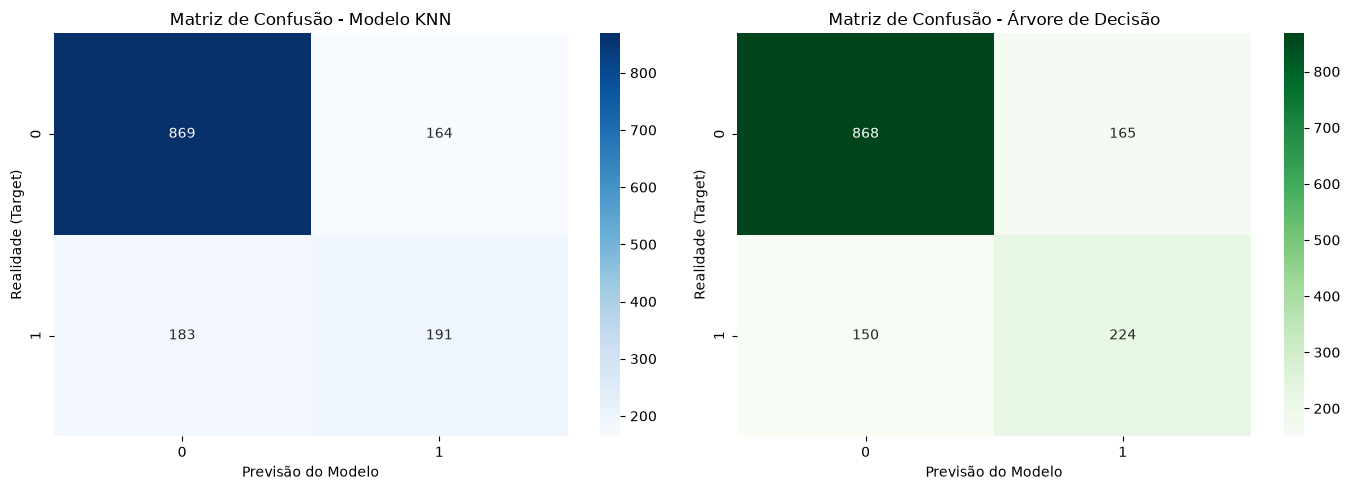

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# DEFINIÇÃO DOS MODELOS FINAIS
# Re-treinando o melhor KNN encontrado na Fase 2
modelo_knn_final = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
modelo_knn_final.fit(atributos_treinamento_padronizados, rotulos_treinamento)
previsoes_teste_knn = modelo_knn_final.predict(atributos_teste_padronizados)

# Re-treinando a melhor Árvore de Decisão encontrada na Fase 2
modelo_arvore_final = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore_final.fit(atributos_treinamento, rotulos_treinamento)
previsoes_teste_arvore = modelo_arvore_final.predict(atributos_teste)


# RELATÓRIOS DE MÉTRICAS (Acurácia, Precisão, Recall e F1-Score)
print("="*55)
print("RELATÓRIO DE MÉTRICAS - MODELO KNN")
print("="*55)
# O classification_report já calcula todas as métricas exigidas automaticamente
print(classification_report(rotulos_teste, previsoes_teste_knn))

print("\n" + "="*55)
print("RELATÓRIO DE MÉTRICAS - ÁRVORE DE DECISÃO")
print("="*55)
print(classification_report(rotulos_teste, previsoes_teste_arvore))


# MATRIZES DE CONFUSÃO
figura_matrizes, eixos_graficos = plt.subplots(1, 2, figsize=(14, 5))

# Plotando a Matriz do KNN
matriz_confusao_knn = confusion_matrix(rotulos_teste, previsoes_teste_knn)
sns.heatmap(matriz_confusao_knn, annot=True, fmt='d', cmap='Blues', ax=eixos_graficos[0])
eixos_graficos[0].set_title('Matriz de Confusão - Modelo KNN')
eixos_graficos[0].set_xlabel('Previsão do Modelo')
eixos_graficos[0].set_ylabel('Realidade (Target)')

# Plotando a Matriz da Árvore de Decisão
matriz_confusao_arvore = confusion_matrix(rotulos_teste, previsoes_teste_arvore)
sns.heatmap(matriz_confusao_arvore, annot=True, fmt='d', cmap='Greens', ax=eixos_graficos[1])
eixos_graficos[1].set_title('Matriz de Confusão - Árvore de Decisão')
eixos_graficos[1].set_xlabel('Previsão do Modelo')
eixos_graficos[1].set_ylabel('Realidade (Target)')

# Ajusta o layout para não cortar os textos e exibe o gráfico
plt.tight_layout()
plt.show()